## ``DL-Regression Model - FIFA``

##### ``Sandra Ranilla-Cortina``

In [ ]:
# Libraries
import pandas as pd
import numpy as np
from math import pi

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# FIFA dataset
df_fifa = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-DL/data/FIFA/FIFA-Dataset.csv')
df_fifa.drop(['sofifa_id', 'player_url', 'long_name', 'ls', 'st', 'rb', 'rcb', 'cb', 'lcb', 'lb', 'rwb', 'rdm', 'cdm', 'ldm', 'lwb', 'rm', 'rcm', 'cm', 'rs', 'lcm', 'lm', 'ram', 'cam', 'lam', 'rw', 'rf', 'cf', 'lf', 'lw'], axis = 1, inplace = True)
df_fifa.head(5)

,short_name,age,dob,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,L. Messi,33,1987-06-24,170,72,Argentina,FC Barcelona,Spain Primera Division,1.0,93,...,75,96,NaN,35,24,6,11,15,14,8
1,Cristiano Ronaldo,35,1985-02-05,187,83,Portugal,Juventus,Italian Serie A,1.0,92,...,84,95,NaN,32,24,7,11,15,14,11
2,J. Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,Spain Primera Division,1.0,91,...,11,68,NaN,12,18,87,92,78,90,90
3,R. Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,German 1. Bundesliga,1.0,91,...,88,88,NaN,42,19,15,6,12,8,10
4,Neymar Jr,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,French Ligue 1,1.0,91,...,92,93,NaN,30,29,9,9,15,15,11


In [3]:
# Features type
df_fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18944 entries, 0 to 18943
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   short_name                  18944 non-null  object 
 1   age                         18944 non-null  int64  
 2   dob                         18944 non-null  object 
 3   height_cm                   18944 non-null  int64  
 4   weight_kg                   18944 non-null  int64  
 5   nationality                 18944 non-null  object 
 6   club_name                   18719 non-null  object 
 7   league_name                 18719 non-null  object 
 8   league_rank                 18719 non-null  float64
 9   overall                     18944 non-null  int64  
 10  potential                   18944 non-null  int64  
 11  value_eur                   18944 non-null  int64  
 12  wage_eur                    18944 non-null  int64  
 13  player_positions            189

In [4]:
# Features description
df_fifa.describe()

,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18944.000000,18944.000000,18944.000000,18719.000000,18944.000000,18944.000000,1.894400e+04,18944.000000,18944.000000,18944.000000,...,18944.000000,18944.000000,0.0,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000
mean,25.225823,181.190773,75.016892,1.357070,65.677787,71.086729,2.224813e+06,8675.852513,1.091850,2.936603,...,48.050412,57.978674,NaN,47.581767,45.546505,16.446052,16.236486,16.103357,16.225982,16.551309
std,4.697354,6.825672,7.057140,0.739327,7.002278,6.109985,5.102486e+06,19654.774894,0.361841,0.667132,...,15.671721,12.118390,NaN,21.402461,20.953997,17.577332,16.845480,16.519399,17.017341,17.878121
min,16.000000,155.000000,50.000000,1.000000,47.000000,47.000000,0.000000e+00,0.000000,1.000000,1.000000,...,6.000000,12.000000,NaN,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.000000,176.000000,70.000000,1.000000,61.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,...,38.750000,50.000000,NaN,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,25.000000,181.000000,75.000000,1.000000,66.000000,71.000000,6.500000e+05,3000.000000,1.000000,3.000000,...,49.000000,59.000000,NaN,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,29.000000,186.000000,80.000000,1.000000,70.000000,75.000000,1.800000e+06,7000.000000,1.000000,3.000000,...,60.000000,66.000000,NaN,65.000000,63.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,53.000000,206.000000,110.000000,4.000000,93.000000,95.000000,1.055000e+08,560000.000000,5.000000,5.000000,...,92.000000,96.000000,NaN,93.000000,90.000000,90.000000,92.000000,93.000000,91.000000,90.000000


#### ``Data Pre-Processing``

In [5]:
# Feature Engineering

# Dates
df_fifa['dob'] = pd.to_datetime(df_fifa['dob'])
df_fifa['born_year'] = df_fifa['dob'].dt.year

# Value
df_fifa['value_eur'] = df_fifa['value_eur'] / 1000000
df_fifa['wage_eur'] = (df_fifa['wage_eur'] * 48) / 1000000
df_fifa['release_clause_eur'] = df_fifa['release_clause_eur'] / 1000000

# League Value
df_fifa['league_value'] = df_fifa.groupby('league_name')['value_eur'].transform('sum') / 1000

# Team Position
df_fifa['team_position'] = df_fifa['team_position'].apply(lambda x: 'Attack' if x in ['LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW'] 
    else ('Denfense' if x in ['LWB', 'LB', 'LCB', 'CB', 'RCB', 'RB'] 
        else ('Midfield' if x in ['LDM', 'CDM', 'RDM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LAM', 'CAM', 'RAM'] 
            else ('GK' if x in ['GK'] else 'None'))))

# Loyalty
df_fifa['joined'] = pd.to_datetime(df_fifa['joined'])
df_fifa['loyalty'] = 2020 - df_fifa['joined'].dt.year

# Loaned Player
df_fifa.loc[df_fifa['loaned_from'].isnull(), 'loaned_from'] = 'None'

# National Team
df_fifa.loc[df_fifa['nation_position'].isnull(), 'nation_position'] = 'None'
df_fifa.loc[df_fifa['nation_jersey_number'].isnull(), 'nation_jersey_number'] = -1

# Player Fame
df_fifa['body_type'] = df_fifa['body_type'].apply(lambda x: 'not_famous' if x.startswith('PLAYER_BODY_TYPE_') else 'famous')

# Number of Player Traits and Tags
df_fifa['player_traits'] = df_fifa['player_traits'].apply(lambda x: len(x.split(',')) if type(x) == str else 0)
df_fifa['player_tags'] = df_fifa['player_tags'].apply(lambda x: len(x.split(',')) if type(x) == str else 0)

# Team Quality
valuable_teams = df_fifa.groupby('club_name')[['value_eur']].sum().sort_values(by = 'value_eur',ascending = False).head(500)
df_fifa['team_quality'] = df_fifa['club_name'].apply(lambda x: 'hight' if x in valuable_teams.index else 'low')

df_fifa.drop(columns = ['dob', 'joined', 'defending_marking'], inplace = True)
print(df_fifa.shape)
df_fifa.head(5)

(18944, 78)


,short_name,age,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,potential,...,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,born_year,league_value,loyalty,team_quality
0,L. Messi,33,170,72,Argentina,FC Barcelona,Spain Primera Division,1.0,93,93,...,24,6,11,15,14,8,1987,5.266865,16.0,hight
1,Cristiano Ronaldo,35,187,83,Portugal,Juventus,Italian Serie A,1.0,92,92,...,24,7,11,15,14,11,1985,3.984970,2.0,hight
2,J. Oblak,27,188,87,Slovenia,Atlético Madrid,Spain Primera Division,1.0,91,93,...,18,87,92,78,90,90,1993,5.266865,6.0,hight
3,R. Lewandowski,31,184,80,Poland,FC Bayern München,German 1. Bundesliga,1.0,91,91,...,19,15,6,12,8,10,1988,3.858735,6.0,hight
4,Neymar Jr,28,175,68,Brazil,Paris Saint-Germain,French Ligue 1,1.0,91,91,...,29,9,9,15,15,11,1992,2.948835,3.0,hight


In [6]:
# NA-values

# Remove NAs (225 players without any info)
na_special_case = df_fifa[df_fifa['club_name'].isnull()].index.tolist()
df_fifa.drop(index = na_special_case, inplace = True)

# Impute NAs (rest of NAs)
na_cols = []
for col in df_fifa.columns.tolist():
    if df_fifa[col].isnull().sum() > 0:
        na_cols.append(col)
na_cols_num = df_fifa[na_cols].select_dtypes(include = ['float64', 'int64', 'int32']).columns
imputer_num = SimpleImputer(strategy = 'median')
df_fifa[na_cols_num] = imputer_num.fit_transform(df_fifa[na_cols_num]).squeeze()

In [7]:
# Numerical features
sc = StandardScaler()
num_features = df_fifa.select_dtypes(include = ['int32']).columns
for col in num_features:
    df_fifa[[col]] = sc.fit_transform(df_fifa[[col]])

In [8]:
# Categorical features
encoder = LabelEncoder()
cat_features = df_fifa.select_dtypes(include = ['object', 'category']).columns
for col in cat_features:
    if col != 'short_name':
        df_fifa[col] = encoder.fit_transform(df_fifa[col])

In [9]:
# Feature Selection + Target
X = df_fifa.drop(['value_eur', 'short_name'], axis = 1)
Y = df_fifa['value_eur']
print(X.shape)
print(Y.shape)

(18719, 76)
(18719,)


In [10]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(14039, 76)
(14039,)
(4680, 76)
(4680,)


#### ``Visualization``

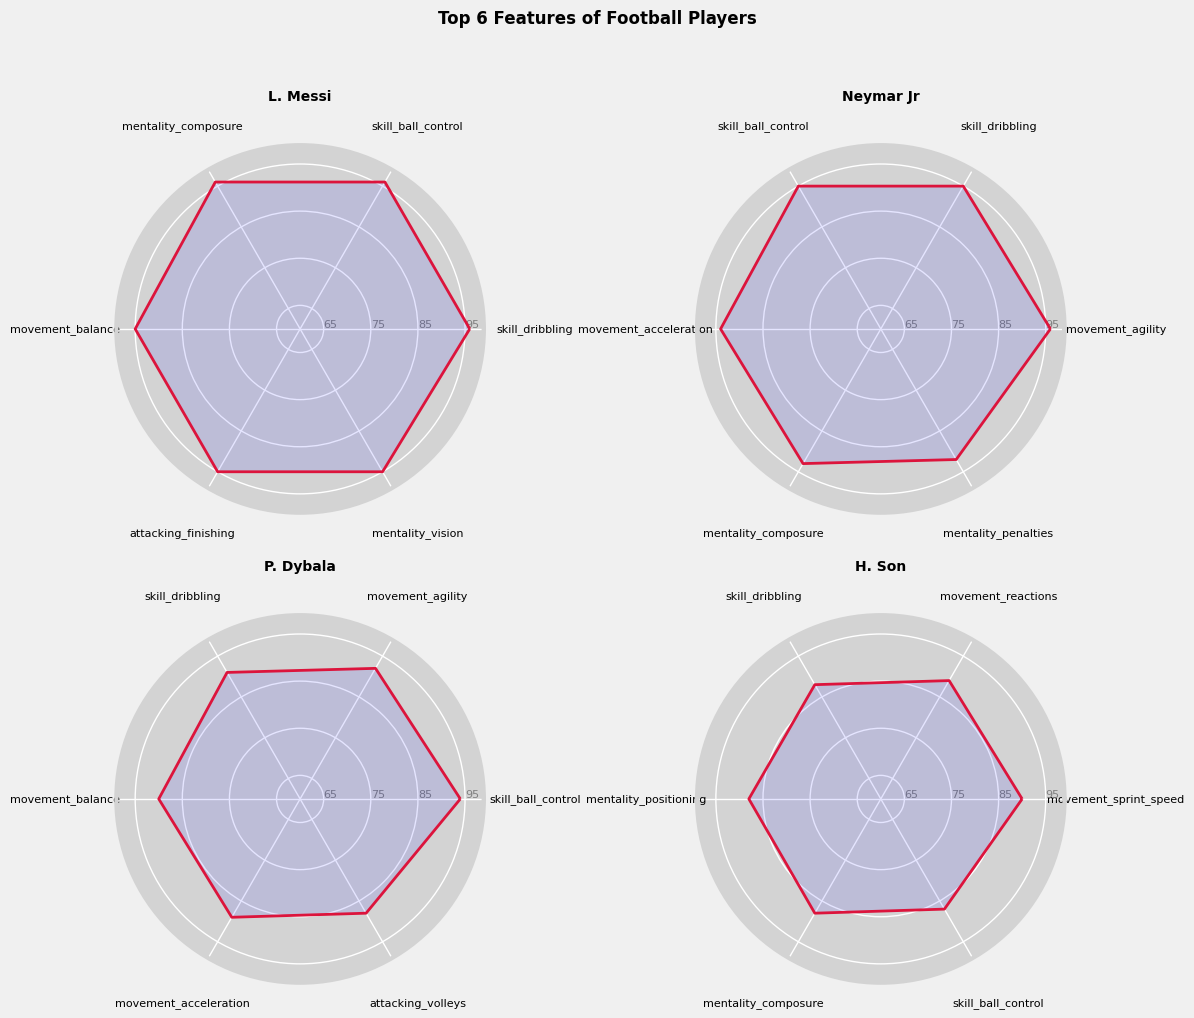

In [11]:
# Visualization of Top 6 Features of Football Players

# List of players
player_names = ['L. Messi', 'Neymar Jr', 'P. Dybala', 'H. Son']

# Player Features
player_features = [
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 
    'movement_reactions', 'movement_balance', 'skill_dribbling', 
    'skill_ball_control', 'attacking_crossing', 'attacking_finishing', 
    'attacking_heading_accuracy', 'attacking_short_passing', 
    'attacking_volleys', 'mentality_aggression', 'mentality_interceptions', 
    'mentality_positioning', 'mentality_vision', 'mentality_penalties', 
    'mentality_composure', 'defending_standing_tackle', 
    'defending_sliding_tackle', 'goalkeeping_diving', 'goalkeeping_handling', 
    'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes'
]

# Plot
fig, axs = plt.subplots(2, 2, figsize = (12, 10), subplot_kw = dict(polar = True))
axs = axs.flatten()

# Loop
for idx, player_name in enumerate(player_names):
    ax = axs[idx]

    # Top 6 Features
    player_data = df_fifa[df_fifa['short_name'] == player_name].iloc[0]
    player_features_data = player_data[player_features].astype(float)
    top_features = player_features_data.nlargest(6)
    categories = top_features.index
    N = len(categories)

    values = top_features.values.tolist()
    values += values[:1]
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    ax.plot(angles, values, linewidth = 2, linestyle = 'solid', label = f'Player: {player_name}', color = 'crimson')
    ax.fill(angles, values, 'b', alpha = 0.1)
    ax.set_xticks(angles[:-1])
    labels = categories
    ax.set_xticklabels(categories, color = 'black', size = 8, position = (-0.8, -0.2))
    ax.set_rlabel_position(0)
    ax.set_ylim(60, 99)
    ax.set_yticks([65, 75, 85, 95])
    ax.set_yticklabels(['65', '75', '85', '95'], color = 'grey', size = 8)
    ax.set_title(player_name, size = 10, fontweight = 'bold', y = 1.1)
    ax.spines['polar'].set_color('lightgrey')
    ax.set_facecolor('#D3D3D3')
    ax.grid(color = 'white')

plt.suptitle('Top 6 Features of Football Players', fontsize = 12, fontweight = 'bold', y = 1.02)
plt.tight_layout();

#### ``Machine Learning Modeling``

In [12]:
# Models
models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(max_depth = 5, min_samples_split = 10, random_state = 1),
    'KNN': KNeighborsRegressor(n_neighbors = 5),
    'Random Forest': RandomForestRegressor(n_estimators = 100, max_depth = 10, min_samples_split = 10,random_state = 1)
}

# Training
results = {}
for model_name, model in models.items():
    # Training
    model.fit(X_train, Y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(Y_test, y_pred)
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    results[model_name] = {'MSE': mse, 'MAE': mae, 'R²': r2}

# Results
results_df = pd.DataFrame(results).T
results_df

,MSE,MAE,R²
Linear Regression,0.538950,0.321686,0.981007
SVR,24.015891,1.520482,0.153654
Decision Tree,0.798664,0.338948,0.971854
KNN,7.754450,1.024863,0.726725
Random Forest,0.472073,0.143776,0.983364


Based on the evaluation metrics, the **``Random Forest Regressor``** clearly outperforms the other models. It achieves the lowest **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)**, as well as the highest **R²** score, indicating that it explains a large proportion of the variance in the target variable.

This strong performance is likely due to its ability to capture complex nonlinear relationships and reduce overfitting through ensemble learning. Compared to simpler models like **Linear Regression** or **Decision Tree**, the **Random Forest** provides a more robust and accurate prediction.

#### ``Deep Learning Modeling``

In [13]:
# Neural Network model
model_nn = Sequential(name = 'Model_NN')

model_nn.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],), kernel_regularizer = l2(0.001), name = 'hidden_layer_1'))
model_nn.add(Dropout(0.2, name = 'dropout_1'))

model_nn.add(Dense(32, activation = 'relu', name = 'hidden_layer_3'))

model_nn.add(Dense(1, name = 'output_layer'))

model_nn.summary()

Model: "Model_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 7,041 (27.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compilation + Training
model_nn.compile(loss = 'mse', optimizer = Adam(learning_rate = 0.01), metrics = ['mae'])
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)
history_nn = model_nn.fit(X_train, Y_train, epochs = 1000, batch_size = 64, validation_split = 0.2, verbose = 1, callbacks = [early_stopping])

Epoch 1/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8925.1992 - mae: 41.2358 - val_loss: 14.0605 - val_mae: 2.2753
Epoch 2/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 27.0415 - mae: 3.5829 - val_loss: 1.8801 - val_mae: 0.8343
Epoch 3/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - loss: 9.7205 - mae: 1.9945 - val_loss: 3.4176 - val_mae: 1.0809
Epoch 4/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 6.8377 - mae: 1.5935 - val_loss: 1.2525 - val_mae: 0.6904
Epoch 5/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 5.8262 - mae: 1.4510 - val_loss: 2.4423 - val_mae: 1.0433
Epoch 6/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 4.6321 - mae: 1.3866 - val_loss: 1.3775 - val_mae: 0.7112
Epoch 7/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - loss: 5.8731 - mae: 1.4885 - val_loss: 1.7946 - val_mae: 1.0718
Epoch 8/1000
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - loss: 4.1840 - mae: 1.2572 - val_loss: 2.7728 - val_mae: 0.9038
Epoch 9/1000
176/176

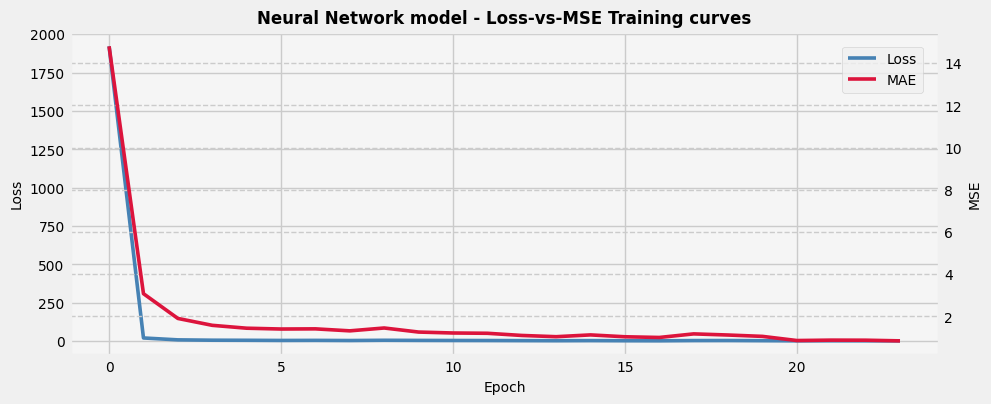

In [15]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_nn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_nn.history['mae'], label = 'MAE', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('MSE', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.86), fontsize = 10);

In [16]:
# Model Prediction
y_test_pred = model_nn.predict(X_test, verbose = 0)

# Evaluation
mae_nn = mean_absolute_error(Y_test, y_test_pred)
mse_nn = mean_squared_error(Y_test, y_test_pred)
r2_nn = r2_score(Y_test, y_test_pred)
print(f'Neural Network model \n -> MAE = {mae_nn:.4f} \n -> MSE = {mse_nn:.4f} \n -> R²: = {r2_nn:.4f}')

Neural Network model 
 -> MAE = 0.4937 
 -> MSE = 0.7725 
 -> R²: = 0.9728


Among all the models evaluated, the **``Random Forest model``** performs very well, achieving the lowest **Mean Absolute Error (MAE)** of $0.1437$, the lowest **Mean Squared Error (MSE)** of $0.4721$, and the highest **R²** score of $0.9834$. This makes it the best-performing model in terms of prediction accuracy.

On the other hand, the **Neural Network model** also **performs strongly**, with a **MAE** of $0.4937$, an **MSE** of $0.7725$, and an **R²** of $0.9728$. Although these values are not as low as those of **Random Forest**, they are still **quite competitive** and indicate that the **Neural Network** captures the data's patterns effectively, though slightly less accurately.